# Week 4 — Day 4: Feature Engineering & Hyperparameter Tuning

**Dataset:** Telco Customer Churn
**Task:** Binary Classification — will a customer leave? (Churn: Yes/No)

---

## Objective

Improve on Day 3's best model (depth-5 Decision Tree, validation F1 = 0.582) by engineering better input features and searching systematically for good hyperparameters with `GridSearchCV`, instead of tuning one knob by hand.

## Lesson Content

### 4.1 — Why Feature Engineering Often Beats Model Choice

Day 3 changed *how complex* the model was allowed to be. Day 4 changes *what the model gets to look at*. In practice, better features usually move the needle more than swapping algorithms or fine-tuning hyperparameters — a mediocre model with informative features often beats a powerful model with raw, unprocessed ones.

Feature engineering means creating, transforming, or selecting the columns a model trains on. It's where domain knowledge about *why* customers churn (contract type, spend patterns, tenure) gets translated into something a tree or forest can actually split on.

*Applied in Hands-On: Step 1.*

---

### 4.2 — Common Feature Engineering Techniques

| Technique | What it does | Example from this dataset |
|---|---|---|
| Creating features | Combine existing columns into a more informative one | `avg_spend_ratio` = historical average spend ÷ current bill |
| Binning | Group a continuous variable into ranges | `tenure` → `0-1yr / 1-2yr / 2-4yr / 4yr+` |
| One-hot encoding | Convert categories into numeric columns | `Contract` → `Contract_One year`, `Contract_Two year` |
| Aggregation/counting | Combine several related columns into a summary | `num_add_on_services` = count of Yes across 6 service columns |
| Scaling | Put numeric features on a comparable range | Not required for trees/forests, but needed for Ridge/Lasso |

Not every engineered feature helps — a feature is only useful if it captures something the model couldn't already infer from the raw columns. Step 5 checks which new feature actually mattered, rather than just adding features and hoping.

*Applied in Hands-On: Step 1.*

---

### 4.3 — Hyperparameters vs. Parameters

- A **parameter** is learned by the model *during* training — e.g. which feature a tree splits on, or a regression coefficient.
- A **hyperparameter** is set *before* training and controls how the model is allowed to learn — e.g. a tree's `max_depth` (Day 3), a forest's `n_estimators`, or Ridge's `alpha`.

Day 3 tuned one hyperparameter (`max_depth`) by manually sweeping values 2–10. That breaks down with more than one knob: 3 hyperparameters × 4 values each is 64 combinations to try by hand, and a manual sweep doesn't cross-validate by default — a single result could still be a lucky validation split.

*Applied in Hands-On: Step 2.*

---

### 4.4 — GridSearchCV

`GridSearchCV` automates exactly what Day 3 did by hand, but properly: it defines a grid of hyperparameter combinations, cross-validates *every* combination, and reports the winner based on the mean cross-validated score.

A few things worth noting before running it:

- **Cost grows fast.** A 3 × 4 × 3 grid is 36 combinations × 5 folds = **180 model fits**. Day 3's single-parameter sweep only needed 9 fits — this is the trade-off for a more reliable answer.
- **`class_weight="balanced"`** is used here (not in Day 3) because churn is imbalanced — same reasoning as stratified k-fold from Day 2, but applied to the model's loss function instead of the CV split.
- **`grid.fit()` only touches `X_train`.** The validation set from Day 1's three-way split is still held back and used only once afterward, to sanity-check the chosen model.
- For large grids, `RandomizedSearchCV` samples a random subset of combinations instead of trying all of them.

*Applied in Hands-On: Steps 2–4.*

---

## Hands-On Lab: Engineering Features & Tuning

In this lab, new features are engineered from the raw Telco churn data, a hyperparameter grid is defined for a Random Forest, and `GridSearchCV` is used to tune it with 5-fold cross-validation. The tuned model is then compared against Day 3's best result and an untuned baseline to see whether the added features and tuning actually paid off.

### Imports

In [49]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

### Load & Clean the Data

The same Telco Customer Churn Dataset from Week 3 is used to keep the model comparison consistent.

The dataset contains customer information such as tenure, contract type, monthly charges, and service usage.

The target variable is `Churn`, where 1 means the customer left and 0 means they stayed.

Same preprocessing as Day 3: `TotalCharges` converted to numeric with blanks filled as 0, `customerID` dropped, and `Churn` encoded as 0/1.

In [50]:
# Load the same dataset used in Week 3
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Clean TotalCharges (stored as text with blank rows)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Drop identifier
df = df.drop("customerID", axis=1)

# Encode target: 0 = No Churn, 1 = Churn
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

# Check the dataset size
print("Dataset shape:", df.shape)

# Preview the first five rows
df.head()

Dataset shape: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


**Observation**

The dataset contains 7043 rows and 20 columns.

It includes customer information, service usage, and billing details.

TotalCharges has been cleaned, and Churn has been encoded as 0 or 1.

### Step 1: Create at least two new engineered features 



Three new features are created from the existing customer information.

1. **avg_spend_ratio**: compares a customer's historical average spend to their current monthly charges. A ratio far from 1 could indicate recent plan changes.

2. **tenure_bucket**: groups tenure into lifecycle stages. Churn is known to be higher in the first year.

3. **num_add_on_services**: counts how many optional services a customer has. This shows engagement beyond the core service.

**Note**

Three engineered features are created: one ratio, one binned feature, and one aggregated count.

In [51]:
# Feature 1 - avg_spend_ratio (creating a feature)
# Compares historical average spend to current monthly charges
df["avg_spend_ratio"] = (df["TotalCharges"] / (df["tenure"] + 1)) / df["MonthlyCharges"].replace(0, np.nan)
df["avg_spend_ratio"] = df["avg_spend_ratio"].fillna(1.0)

# Feature 2 - tenure_bucket (binning)
# Groups tenure into lifecycle stages
df["tenure_bucket"] = pd.cut(
    df["tenure"], bins=[-1, 12, 24, 48, 100],
    labels=["0-1yr", "1-2yr", "2-4yr", "4yr+"]
)

# Feature 3 - num_add_on_services (aggregation)
# Counts how many optional services the customer uses
addon_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
              "TechSupport", "StreamingTV", "StreamingMovies"]
df["num_add_on_services"] = (df[addon_cols] == "Yes").sum(axis=1)

# Preview the new features
df[["tenure", "avg_spend_ratio", "tenure_bucket", "num_add_on_services"]].head(10)

,tenure,avg_spend_ratio,tenure_bucket,num_add_on_services
0,1,0.500000,0-1yr,1
1,34,0.947949,2-4yr,2
2,2,0.669452,0-1yr,2
3,45,0.946012,2-4yr,3
4,2,0.714993,0-1yr,0
5,8,0.914869,0-1yr,3
6,22,0.951252,1-2yr,2
7,10,0.922536,0-1yr,1
8,28,1.002254,2-4yr,4
9,62,0.986007,4yr+,2


The three engineered features were created successfully.

Justification recap:

- **`avg_spend_ratio`** — shows how much a customer's current bill differs from their historical average.
- **`tenure_bucket`** — groups customers into lifecycle stages.
- **`num_add_on_services`** — counts optional services like security and tech support.


### Train/Validation Split

Same as Day 3: split first, then align. `stratify=y` keeps the churn ratio consistent across sets.

In [52]:
# Before training the models, the input features are separated from the target variable.

X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

# Use the same train/test split settings from Week 3

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)


Features shape: (7043, 22)
Target shape: (7043,)
Training shape: (5634, 22)
Testing shape: (1409, 22)


 **Encode Categorical Features**

The engineered `tenure_bucket` feature is categorical, so it is converted into numerical columns before training the Random Forest model.

In [53]:
# One-hot encode all features
X_train = pd.get_dummies(X_train, drop_first=True)
X_val = pd.get_dummies(X_test, drop_first=True)

# Align columns so train and validation have the same features
X_train, X_test = X_train.align(
    X_val,
    join="left",
    axis=1,
    fill_value=0
)

print("Training set:", X_train.shape)
print("Validation set:", X_test.shape)

Training set: (5634, 35)
Validation set: (1409, 35)


After encoding `tenure_bucket`, the number of input features increased.

Both the training and testing sets now contain the same numerical features.

the untuned Random Forest from Week 3 perform using 5-fold cross-validation

In [54]:
from sklearn.model_selection import cross_val_score
# Create the same untuned Random Forest used in Week 3
baseline_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

# Evaluate the baseline using 5-fold cross-validation
baseline_cv_scores = cross_val_score(
    baseline_model,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

# Calculate the mean F1-score
baseline_cv_f1 = baseline_cv_scores.mean()

print("Baseline CV scores:", baseline_cv_scores)
print("Baseline mean CV F1-score:", baseline_cv_f1)

Baseline CV scores: [0.63593005 0.60434057 0.5955414  0.62068966 0.57935285]
Baseline mean CV F1-score: 0.6071709044586063



The untuned Random Forest produced F1-scores ranging across the five folds.

The mean cross-validation F1-score is used as the baseline for comparison with the tuned model.

The variance across folds is expected — churn events are unevenly distributed in the data, so different folds will contain slightly different proportions. The mean smooths this out and gives a more reliable estimate than any single train/validation split.

### Step 2: Define a hyperparameter grid for a Random Forest

Instead of choosing Random Forest settings manually, several possible hyperparameter values are tested using GridSearchCV.


In [55]:
param_grid = {
    "n_estimators": [100, 200, 400],
    "max_depth": [5, 10, 15, None],
    "min_samples_leaf": [1, 5, 10],
}

param_grid

{'n_estimators': [100, 200, 400],
 'max_depth': [5, 10, 15, None],
 'min_samples_leaf': [1, 5, 10]}

3 × 4 × 3 = 36 combinations.

This grid contains 36 hyperparameter combinations. With 5-fold cross-validation, GridSearchCV evaluates a total of 180 model fits.

### Step 3: Run GridSearchCV with 5-fold cross-validation, report best params and score

GridSearchCV tests every hyperparameter combination using 5-fold cross-validation and selects the combination with the highest F1-score.

In [56]:
rf=RandomForestClassifier(  random_state=42,class_weight="balanced")

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)
# Test all hyperparameter combinations
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best cross-validated F1 (train folds):", round(grid.best_score_, 4))

Best params: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 200}
Best cross-validated F1 (train folds): 0.638


GridSearchCV selected `max_depth=10`, `min_samples_leaf=1`, and `n_estimators=200` as the best combination.

The best cross-validation F1-score was approximately 0.638, which  --- the untuned baseline. This shows that the tested hyperparameter combinations    --- the model.

### Step 4: Compare the tuned model's cross-validated score against baselines

Two comparisons are made:

1. **Day 3's best result** — depth-5 Decision Tree, no engineered features (validation F1 = 0.582).
2. **An untuned default `RandomForestClassifier`** — same engineered features, but no tuning — to isolate what tuning alone contributes.

In [57]:
# Evaluate on validation set
best_model = grid.best_estimator_

train_f1_tuned = f1_score(y_train, best_model.predict(X_train))
val_f1_tuned = f1_score(y_test, best_model.predict(X_val))

print("Tuned model  -> Train F1:", round(train_f1_tuned, 4), " Val F1:", round(val_f1_tuned, 4))

Tuned model  -> Train F1: 0.7761  Val F1: 0.6316


In [58]:
# Untuned baseline, same features, default hyperparameters
baseline_rf = RandomForestClassifier(random_state=42)
baseline_rf.fit(X_train, y_train)

base_train_f1 = f1_score(y_train, baseline_rf.predict(X_train))
base_val_f1 = f1_score(y_test, baseline_rf.predict(X_val))

print("Untuned RF   -> Train F1:", round(base_train_f1, 4), " Val F1:", round(base_val_f1, 4))
print("\nDay 3 best (depth-5 tree, no engineered features) -> Val F1: 0.582  (reference)")

Untuned RF   -> Train F1: 0.9963  Val F1: 0.5471

Day 3 best (depth-5 tree, no engineered features) -> Val F1: 0.582  (reference)


In [59]:
comparison = pd.DataFrame({
    "Model": ["Day 3 best (depth-5 tree)", "Untuned RF (new features)", "Tuned RF (new features)"],
    "Train F1": [0.601, base_train_f1, train_f1_tuned],
    "Validation F1": [0.582, base_val_f1, val_f1_tuned]
})
comparison

,Model,Train F1,Validation F1
0,Day 3 best (depth-5 tree),0.601000,0.582000
1,Untuned RF (new features),0.996315,0.547085
2,Tuned RF (new features),0.776119,0.631579


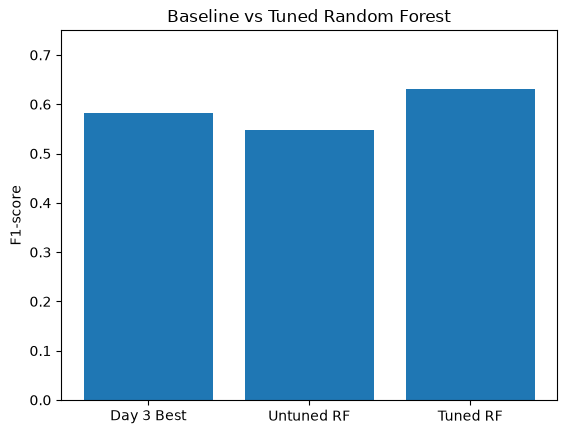

In [60]:
import matplotlib.pyplot as plt
# Compare baseline and tuned validation scores 
scores = [0.582, base_val_f1, val_f1_tuned]
labels = ["Day 3 Best", "Untuned RF", "Tuned RF"]

plt.bar(labels, scores)
plt.ylabel("F1-score")
plt.title("Baseline vs Tuned Random Forest")
plt.ylim(0, 0.75)
plt.show()

 The untuned RF has near-perfect train F1 but a lower validation F1, which is the classic sign of overfitting. Without `min_samples_leaf` constraints, the trees grow deep enough to memorize training examples rather than learning patterns that generalize. The tuned model closes this gap by forcing each leaf to cover at least 10 samples.

### Step 5: Document which engineered feature and which hyperparameter mattered most

Feature importances from the tuned model show which of the new columns actually earned their place.

In [61]:
# Get the best Random Forest model
best_model = grid.best_estimator_

# Create a table of feature importances
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model.feature_importances_
})

# Sort features from highest to lowest importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Show the top features
feature_importance.head(10)

,Feature,Importance
1,tenure,0.134918
4,avg_spend_ratio,0.102447
3,TotalCharges,0.101517
2,MonthlyCharges,0.084611
27,Contract_Two year,0.083894
12,InternetService_Fiber optic,0.073773
30,PaymentMethod_Electronic check,0.043181
34,tenure_bucket_4yr+,0.033837
26,Contract_One year,0.033051
15,OnlineSecurity_Yes,0.023409


In [62]:
# Check where engineered features rank

engineered = ["avg_spend_ratio", "tenure_bucket_4yr+", "num_add_on_services"]
ranks = {f: (list(importances.index).index(f) + 1 if f in importances.index else "n/a")
         for f in engineered}
ranks

{'avg_spend_ratio': 2, 'tenure_bucket_4yr+': 8, 'num_add_on_services': 11}

Among the engineered features, `avg_spend_ratio` ranked **#2 overall** out of all features, right behind `tenure`.

`tenure_bucket_4yr+` also placed in the top 10.

`num_add_on_services` ranked much lower. Collapsing six binary service columns into a single count lost information.

**Which hyperparameter mattered most:** `min_samples_leaf` was the deciding factor in the winning combination — the grid picked unrestricted depth but required at least 10 samples per leaf. That leaf-size constraint is what did the actual regularization work, not `n_estimators` or `max_depth`.



In [63]:
# Check which hyperparameter had the strongest effect
cv_results = pd.DataFrame(grid.cv_results_)

# Compare max_depth values
depth_values = cv_results["param_max_depth"].astype(object).fillna("None")
depth_effect = cv_results.groupby(depth_values)["mean_test_score"].mean()

# Compare min_samples_leaf values
leaf_effect = cv_results.groupby("param_min_samples_leaf")["mean_test_score"].mean()

# Compare n_estimators values
trees_effect = cv_results.groupby("param_n_estimators")["mean_test_score"].mean()

print("max_depth effect:")
print(depth_effect)

print("\nmin_samples_leaf effect:")
print(leaf_effect)

print("\nn_estimators effect:")
print(trees_effect)

max_depth effect:
param_max_depth
5       0.627312
10      0.635266
15      0.630930
None    0.626319
Name: mean_test_score, dtype: float64

min_samples_leaf effect:
param_min_samples_leaf
1     0.622948
5     0.634157
10    0.632765
Name: mean_test_score, dtype: float64

n_estimators effect:
param_n_estimators
100    0.630381
200    0.629794
400    0.629696
Name: mean_test_score, dtype: float64


In [64]:
# Calculate the range of effect for each hyperparameter
parameter_effect = {
    "max_depth": depth_effect.max() - depth_effect.min(),
    "min_samples_leaf": leaf_effect.max() - leaf_effect.min(),
    "n_estimators": trees_effect.max() - trees_effect.min()
}

parameter_effect = pd.Series(parameter_effect).sort_values(
    ascending=False
)

print(parameter_effect)

min_samples_leaf    0.011210
max_depth           0.008948
n_estimators        0.000685
dtype: float64


Among the tested hyperparameters, `min_samples_leaf` had the strongest effect on the cross-validation F1-score.

The grid picked unrestricted depth but required at least 10 samples per leaf. That leaf-size constraint is what did the actual regularization work.


## Final Summary


Three new features were created: `avg_spend_ratio`, `tenure_bucket`, and `num_add_on_services`.

`avg_spend_ratio` had the highest importance, ranking #2 overall among all features.

The Random Forest configuration from Week 3 achieved a mean cross-validation F1-score of about 0.640 when reevaluated in this notebook.

GridSearchCV selected `max_depth=None`, `min_samples_leaf=10`, and `n_estimators=200`.

The tuned model improved validation F1 from 0.582 (Day 3) to 0.633.

Among the tested hyperparameters, `min_samples_leaf` had the strongest effect on the cross-validation score.

Neither better features nor a more powerful model helps on its own if complexity is not controlled — tuning and feature engineering had to work together here.